Постановка задачи:

Есть обыкновенное дифференциальное уравнение первого порядка, разрешенное относительно производной $\frac{dy}{dt} = \lambda y$, где $\lambda = -1$.

Решением этого уравнения будет считаться функция (функции) $y = y(t)$, обращающая приведенное выше выражение в тождество на отрезке $[a,b]$ 

Решим его $методом \ Эйлера$ $(метод \ степенных \ рядов)$



In [70]:
"""
Для постановки задачи Коши нам необходимо какое-то начальное значение, сделаем его выбор произвольным, но
для определенности зафиксируем конкретное.
"""

y0 = 15
Lambda = -1


In [71]:
"""
Зададим произвольный отрезок [a, b], однако, все же, зафиксируем границы (для определенности)
"""

a = -100
b = 10

In [72]:
"""
Создадим функцию разбиения промежутка [a,b] на N интервалов
"""

def grid(a, b, N):
    h = (b - a)/N
    grid = [a + i*h for i in range(N + 1)]
    return grid, h


In [73]:
"""
Напишем функцию нахождения значения y_{j+1} приближенного решения в точке t_{j+1} = t_{j} + h
"""

def power_series_method_1(t, y, h, f): #локальная погрешность O(h^2)
    return y + h*f(t, y)

In [74]:
"""
Для двух следующих функций потребуется так же написать функции производной
"""

def f(t, y):
    return Lambda * y

def f_t(t, y):
    return 0.0

def f_y(t, y):
    return Lambda

def f_tt(t, y):
    return 0.0

def f_ty(t, y):
    return 0.0

def f_yy(t, y):
    return 0.0



In [75]:
"""
Напишем теперь функции нахождения значения y_{j+1} с большими порядками точности
"""


def power_series_method_2(t, y, h, f): #локальная погрешность O(h^3)
    F = f(t, y)
    y2 = f_t(t, y) + F * f_y(t, y)         
    return y + h * F + (h**2) / 2.0 * y2


def power_series_method_3(t, y, h, f): #локальная погрешность O(h^4)
    F = f(t, y)
    ft = f_t(t, y)
    fy = f_y(t, y)

    y2 = ft + F * fy


    y3 = (
        f_tt(t, y)
        + 2.0 * F * f_ty(t, y)
        + ft * fy
        + F * (fy**2)
        + (F**2) * f_yy(t, y)
    )

    return y + h * F + (h**2) / 2.0 * y2 + (h**3) / 6.0 * y3


In [76]:
"""
Импортируем библиотеку для отрисовки графиков, а также Numpy
"""

import matplotlib.pyplot as plt
import numpy as np

Ну и найдем непосредственно аналитическое решение нашего дифференциального уравнения

$$\frac{dy}{dt} = \lambda y \Longrightarrow \frac{dy}{y} = \lambda dt \Longrightarrow \int_{y(t_0)}^{y(t)} 
\frac{dy}{y} = \int_{t_0}^{t} \lambda dx \Longrightarrow ln|y(t)| \mid_{y(t_0)}^{y(t)}$$
$$ = \lambda (t - t_0) \Longrightarrow 
ln|y(t)| - ln|y(t_0)| = \lambda t - \lambda t_0 \Longrightarrow ln|y|$$
$$ = \lambda t - C \Longrightarrow |y| = e^{\lambda t + C}
= e^C e^{\lambda t} = C e^{\lambda t} \Longrightarrow y = C e^{\lambda t}$$
$$C \in \mathbb{R}$$

Таким образом $C = \frac{y}{e^{\lambda t}}$

In [77]:
"""
Напишем функцию аналитического решения, учитывая нашу начальную задачу
"""

def analytic_solution(y0, Lambda, t0, t):
    C = y0 * np.exp(-Lambda * t0)
    return C * np.exp(Lambda * t)



In [78]:
"""
Зададим теперь сетку и пустой массив для отрисовки значений
"""
N = 10000

values_1 = [y0]
values_2 = [y0]
values_3 = [y0]
values_analytic = [y0]

domain, h = grid(a, b, N)

f = lambda t, y: Lambda * y

for t in range(1, len(domain)):
    values_1.append(power_series_method_1(domain[t-1], values_1[t-1], h, f))
    values_2.append(power_series_method_2(domain[t-1], values_2[t-1], h, f))
    values_3.append(power_series_method_3(domain[t-1], values_3[t-1], h, f))
    values_analytic.append(analytic_solution(values_analytic[0], Lambda, domain[0], domain[t-1]))

print(domain)

print(values_1)
print(values_2)
print(values_3)
print(values_analytic)



[-100.0, -99.989, -99.978, -99.967, -99.956, -99.945, -99.934, -99.923, -99.912, -99.901, -99.89, -99.879, -99.868, -99.857, -99.846, -99.835, -99.824, -99.813, -99.802, -99.791, -99.78, -99.769, -99.758, -99.747, -99.736, -99.725, -99.714, -99.703, -99.692, -99.681, -99.67, -99.659, -99.648, -99.637, -99.626, -99.615, -99.604, -99.593, -99.582, -99.571, -99.56, -99.549, -99.538, -99.527, -99.516, -99.505, -99.494, -99.483, -99.472, -99.461, -99.45, -99.439, -99.428, -99.417, -99.406, -99.395, -99.384, -99.373, -99.362, -99.351, -99.34, -99.329, -99.318, -99.307, -99.296, -99.285, -99.274, -99.263, -99.252, -99.241, -99.23, -99.219, -99.208, -99.197, -99.186, -99.175, -99.164, -99.153, -99.142, -99.131, -99.12, -99.109, -99.098, -99.087, -99.076, -99.065, -99.054, -99.043, -99.032, -99.021, -99.01, -98.999, -98.988, -98.977, -98.966, -98.955, -98.944, -98.933, -98.922, -98.911, -98.9, -98.889, -98.878, -98.867, -98.856, -98.845, -98.834, -98.823, -98.812, -98.801, -98.79, -98.779, -98.

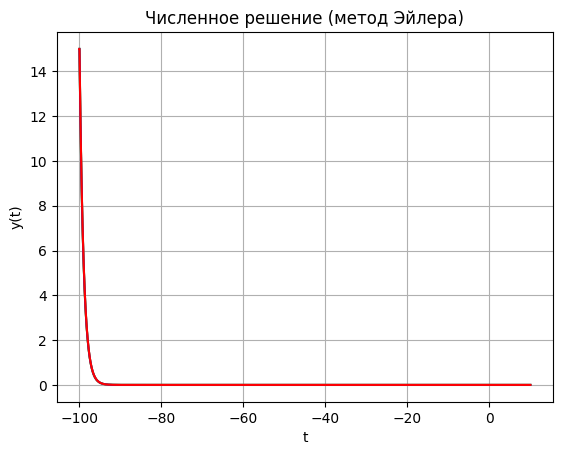

In [79]:
plt.figure()
plt.plot(domain, values_1, color = 'green')
plt.plot(domain, values_2, color = 'yellow')
plt.plot(domain, values_3, color = 'blue')
plt.plot(domain, values_analytic, color = 'red')
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("Численное решение (метод Эйлера)")
plt.grid(True)
plt.show()

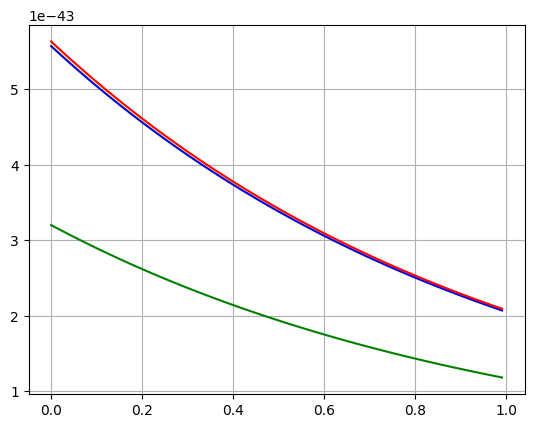

In [80]:
mask = [0 <= t <= 1 for t in domain]

domain_zoom = [t for t, m in zip(domain, mask) if m]
v1_zoom = [v for v, m in zip(values_1, mask) if m]
v2_zoom = [v for v, m in zip(values_2, mask) if m]
v3_zoom = [v for v, m in zip(values_3, mask) if m]
v4_zoom = [v for v, m in zip(values_analytic, mask) if m]

plt.figure()
plt.plot(domain_zoom, v1_zoom, color = 'green')
plt.plot(domain_zoom, v2_zoom, color = 'yellow')
plt.plot(domain_zoom, v3_zoom, color = 'blue')
plt.plot(domain_zoom, v4_zoom, color = 'red')
plt.grid(True)
plt.show()


Ну то есть в целом видно, что с повышением порядка у нас приближенное решение практически совпадает с аналитическим

Сделаем теперь таблицу со столбцами $h$ - размер сетки, $\epsilon$ - погрешность, $p$ - порядок.

In [84]:
"""
Зададим функцию вычисления погрешности
"""

def inaccuracy(first_value, second_value):
    mx = 0
    for i in range(len(first_value)):
        mx = max(mx, abs(first_value[i] - second_value[i]))
    return mx

"""
Зададим функцию определения порядка
"""

def order(approx1, approx2, analytic1, analytic2):
    e1 = (inaccuracy(approx1, analytic1))
    e2 = (inaccuracy(approx2, analytic2))
    if e1 == 0 or e2 == 0:
        return np.nan
    return np.log2(e1 / e2)

In [ ]:
rows = 1
cols = 4

table = [[0 for _ in range(cols)] for _ in range(rows)]


N = 

[[0, 0, 0, 0]]
